# 4. Rispondere alle domande
Trasforma le seguenti richiesti in formule per estrarre infromazioni dal dataframe
- Mostrami le vendite maggiori di 10

- Mostrami i dati del 2018

- Mostrami le vendite maggiori di 13 e l'anno è il 2018

- Mostrami tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

- Mostrami i dati dove le vendite divise per 3 sono maggiori di 3

- Mostrami i dipendenti i cui nomi sono alfabeticamente dopo la J



In [1]:
import pandas as pd

sales = pd.DataFrame(
    data={
        "employee": [
            "Katrina",
            "Guanyu",
            "Jan",
            "Roman",
            "Jacqueline",
            "Paola",
            "Esperanza",
            "Alaina",
            "Egweyn",
        ],
        "sales": [14, 17, 6, 12, 8, 3, 7, 15, 5],
        "year": [2018, 2019, 2020, 2018, 2020, 2019, 2019, 2020, 2020],
    }
)
sales

,employee,sales,year
0,Katrina,14,2018
1,Guanyu,17,2019
2,Jan,6,2020
3,Roman,12,2018
4,Jacqueline,8,2020
5,Paola,3,2019
6,Esperanza,7,2019
7,Alaina,15,2020
8,Egweyn,5,2020


In [27]:
# Vendite maggiori di 10

print('Vendite maggiori di 10: \n', sales.query('sales > 10'))

# I dati del 2018

print('\nDati del 2018: \n', sales.query('year == 2018'))

# Vendite maggiori di 13 e l'anno è il 2018

print('\nVendite maggiori di 13 e l\'anno è il 2018: \n', sales.query('year == 2018 & sales > 13'))

# Tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018

print('\nTutto TRANNE i casi in cui le vendite sono maggiori di 13 e l\'anno è il 2018: \n', sales.query('not (year == 2018 & sales > 13)'))

# I dati dove le vendite divise per 3 sono maggiori di 3

print('\n I dati dove le vendite divise per 3 sono maggiori di 3:\n', sales.query('sales/3 > 3'))

# I dipendenti i cui nomi sono alfabeticamente dopo la J

print('\n I dipendenti i cui nomi sono alfabeticamente dopo la J:\n', sales.query('employee > "J"'))


Vendite maggiori di 10: 
   employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020

Dati del 2018: 
   employee  sales  year
0  Katrina     14  2018
3    Roman     12  2018

Vendite maggiori di 13 e l'anno è il 2018: 
   employee  sales  year
0  Katrina     14  2018

Tutto TRANNE i casi in cui le vendite sono maggiori di 13 e l'anno è il 2018: 
      employee  sales  year
1      Guanyu     17  2019
2         Jan      6  2020
3       Roman     12  2018
4  Jacqueline      8  2020
5       Paola      3  2019
6   Esperanza      7  2019
7      Alaina     15  2020
8      Egweyn      5  2020

 I dati dove le vendite divise per 3 sono maggiori di 3:
   employee  sales  year
0  Katrina     14  2018
1   Guanyu     17  2019
3    Roman     12  2018
7   Alaina     15  2020

 I dipendenti i cui nomi sono alfabeticamente dopo la J:
      employee  sales  year
0     Katrina     14  2018
2         Jan      6  2020
3       Roman     12  2018


# 5. Analisi di un dataset di video giochi
1. Quanti videogiochi sono stati pubblicati
2. Quali sono i generi più popolari? Mostralo con un bar plot
3. Plotta l'evoluzione del numero di giochi pubblicati nel tempo
4. Prova a riprodurre questo plot 

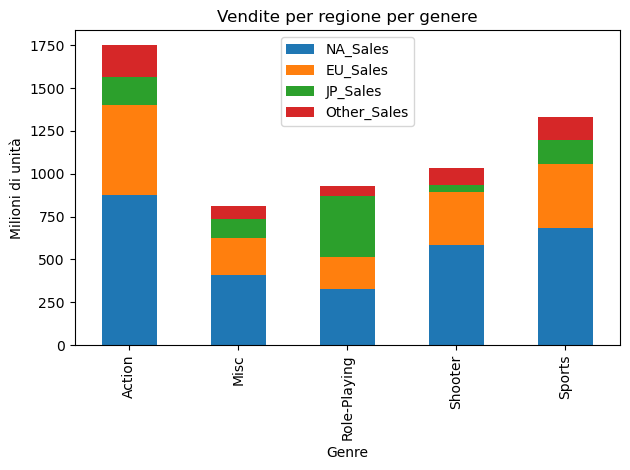


In [102]:
# Import dei pacchetti
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Caricamento del dataset
url = 'https://zenodo.org/record/5898311/files/vgsales.csv'
df = pd.read_csv(url)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [104]:
#Quanti videogiochi sono stati pubblicati
#controllo che non ci siano doppioni
df.drop_duplicates(inplace = True)

print('Numero di videogiochi pubblicati: \n',len(df))

#pulisco il df
df = df.dropna()

#Dopo averlo pulito il numero cambia
print('Numero di videogiochi pubblicati (dataframe pulito): \n',len(df))

Numero di videogiochi pubblicati: 
 16598
Numero di videogiochi pubblicati (dataframe pulito): 
 16291


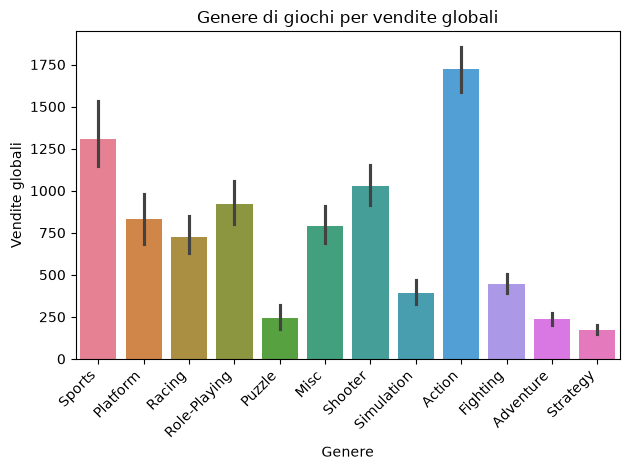

In [105]:
#Quali sono i generi più popolari? Mostralo con un bar plot

sns.barplot(data=df, x= 'Genre', y='Global_Sales', hue = 'Genre', estimator = 'sum')
plt.xticks(rotation = 45, ha = 'right')
plt.title('Genere di giochi per vendite globali')
plt.xlabel('Genere')
plt.ylabel('Vendite globali')
plt.tight_layout()
plt.show()


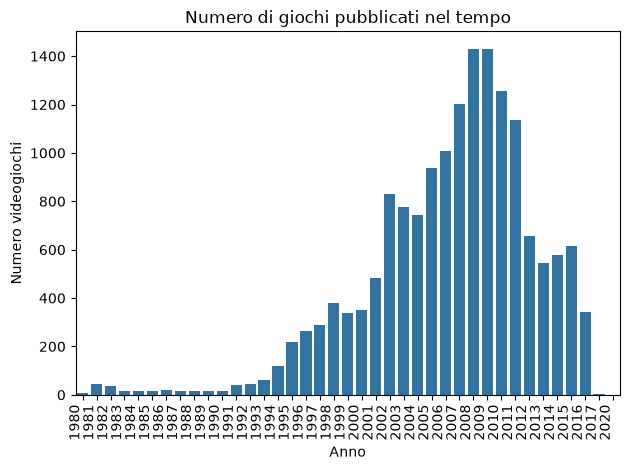

In [74]:
#Plotta l'evoluzione del numero di giochi pubblicati nel tempo

#trasformo gli anni in integer
df['Year'] = df['Year'].astype(int)

#plot
sns.countplot(data = df, x='Year')
plt.xticks(rotation = 90, ha = 'right')
plt.title('Numero di giochi pubblicati nel tempo')
plt.xlabel('Anno')
plt.ylabel('Numero videogiochi')
plt.tight_layout()
plt.show()

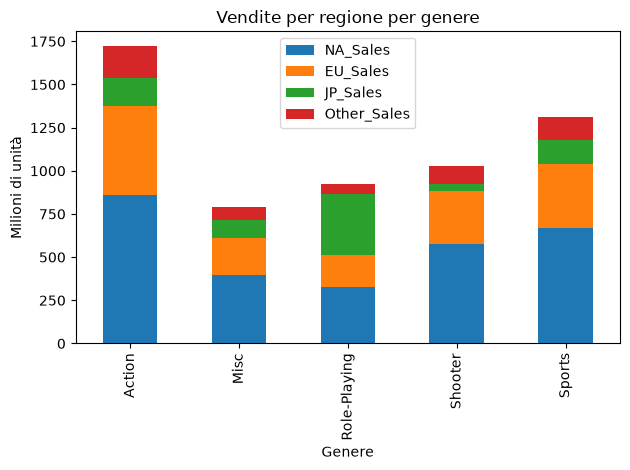

In [ ]:
#riproduzione del plot

#Creo il nuovo df

vendite = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
vendite_per_genere = df_filtrato.groupby('Genre')[vendite].sum()

#plotto
vendite_per_genere.plot(kind='bar', stacked=True)
plt.title('Vendite per regione per genere')
plt.xlabel('Genere')
plt.ylabel('Milioni di unità')
plt.tight_layout()
plt.show()